# Ablation Study — 피처 순차 제거 실험

**목적**: 상관이 높은 피처를 하나씩 제거하면서 성능 변화를 추적한다.  
**기준**: v2 (전체기간 + Return 피처, 14개)  

| 실험 | 제거 피처 | 남은 피처 수 |
|------|-----------|-------------|
| v2 | — | 14 |
| v2.1 | US_CPI | 13 |
| v2.2 | US_CPI + MSFT_Return | 12 |
| v2.3 | US_CPI + MSFT_Return + QQQ_Return | 11 |
| v2.4 | US_CPI + MSFT_Return + NVDA_RSI | 11 |

**LR**: 각 버전 별도 피처셋 적용  
**XGBoost**: v2 기준 유지 (트리 모델은 상관에 덜 민감)

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

np.random.seed(42)

PROCESSED_DIR = Path("../data/processed")
FIG_DIR       = Path("../reports/figures")
RESULTS_DIR   = Path("../reports/results")

train = pd.read_csv(PROCESSED_DIR / "train_v2.csv", index_col=0, parse_dates=True)
val   = pd.read_csv(PROCESSED_DIR / "val_v2.csv",   index_col=0, parse_dates=True)
test  = pd.read_csv(PROCESSED_DIR / "test_v2.csv",  index_col=0, parse_dates=True)

BASE_FEATURES = [
    "NVDA_Return_1D", "NVDA_MA20_ratio", "NVDA_Volume_ratio", "NVDA_RSI", "NVDA_MACD",
    "SOX_Return", "TSM_Return",
    "US_10Y_Yield", "QQQ_Return", "DXY_Return", "US_CPI",
    "VIX",
    "MSFT_Return", "META_Return",
]

# 실험별 피처셋 정의
EXPERIMENTS = {
    "v2":   BASE_FEATURES,
    "v2.1": [f for f in BASE_FEATURES if f not in ["US_CPI"]],
    "v2.2": [f for f in BASE_FEATURES if f not in ["US_CPI", "MSFT_Return"]],
    "v2.3": [f for f in BASE_FEATURES if f not in ["US_CPI", "MSFT_Return", "QQQ_Return"]],
    "v2.4": [f for f in BASE_FEATURES if f not in ["US_CPI", "MSFT_Return", "NVDA_RSI"]],
}

y_train = train["target"].values
y_val   = val["target"].values
y_test  = test["target"].values

majority = max(y_test.mean(), 1 - y_test.mean()) * 100
print(f"실험 버전 수: {len(EXPERIMENTS)}")
print(f"Test Majority baseline: {majority:.1f}%")

실험 버전 수: 5
Test Majority baseline: 52.4%


## 1. LR Ablation

In [2]:
def run_lr(features, name):
    """주어진 피처셋으로 LR을 학습하고 성능을 반환한다."""
    X_tr = train[features].values
    X_va = val[features].values
    X_te = test[features].values

    best_f1, best_c, best_pipe = 0, 1, None
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        pipe = Pipeline([("scaler", StandardScaler()),
                         ("model", LogisticRegression(C=C, max_iter=1000, random_state=42))])
        pipe.fit(X_tr, y_train)
        f1 = f1_score(y_val, pipe.predict(X_va), zero_division=0)
        if f1 > best_f1:
            best_f1, best_c, best_pipe = f1, C, pipe

    prob = best_pipe.predict_proba(X_te)[:, 1]
    pred = best_pipe.predict(X_te)
    return {
        "version":  name,
        "n_features": len(features),
        "removed":  ", ".join(set(BASE_FEATURES) - set(features)) or "—",
        "best_C":   best_c,
        "accuracy": round(accuracy_score(y_test, pred) * 100, 2),
        "f1":       round(f1_score(y_test, pred, zero_division=0), 4),
        "roc_auc":  round(roc_auc_score(y_test, prob), 4),
    }

lr_results = []
for name, features in EXPERIMENTS.items():
    result = run_lr(features, name)
    lr_results.append(result)
    print(f"{name} ({result['n_features']}개)  Acc={result['accuracy']}%  ROC-AUC={result['roc_auc']}")

lr_df = pd.DataFrame(lr_results)
print()
print(lr_df[["version", "n_features", "removed", "accuracy", "f1", "roc_auc"]].to_string(index=False))

v2 (14개)  Acc=54.67%  ROC-AUC=0.5763
v2.1 (13개)  Acc=53.33%  ROC-AUC=0.5751
v2.2 (12개)  Acc=53.33%  ROC-AUC=0.5742
v2.3 (11개)  Acc=53.78%  ROC-AUC=0.5724
v2.4 (11개)  Acc=53.78%  ROC-AUC=0.5744

version  n_features                         removed  accuracy     f1  roc_auc
     v2          14                               —     54.67 0.6852   0.5763
   v2.1          13                          US_CPI     53.33 0.6866   0.5751
   v2.2          12             US_CPI, MSFT_Return     53.33 0.6866   0.5742
   v2.3          11 US_CPI, MSFT_Return, QQQ_Return     53.78 0.6905   0.5724
   v2.4          11   US_CPI, MSFT_Return, NVDA_RSI     53.78 0.6886   0.5744


## 2. 시각화

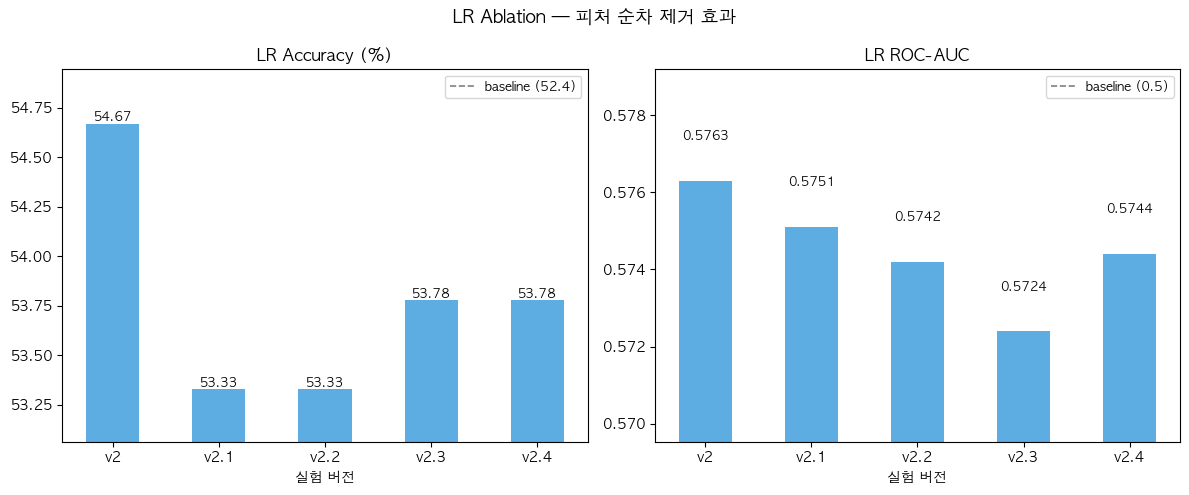

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

versions = lr_df["version"]

for ax, metric, title, baseline in [
    (axes[0], "accuracy", "Accuracy (%)", majority),
    (axes[1], "roc_auc",  "ROC-AUC",      0.5),
]:
    bars = ax.bar(versions, lr_df[metric], color="#3498db", alpha=0.8, width=0.5)
    ax.axhline(baseline, color="gray", linestyle="--", linewidth=1.2,
               label=f"baseline ({baseline:.1f})")
    ax.set_title(f"LR {title}", fontsize=12)
    ax.set_xlabel("실험 버전")
    ax.legend(fontsize=9)
    ax.set_ylim(min(lr_df[metric]) * 0.995, max(lr_df[metric]) * 1.005)
    for bar, val in zip(bars, lr_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                str(val), ha="center", va="bottom", fontsize=9)

plt.suptitle("LR Ablation — 피처 순차 제거 효과", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_lr.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. 최종 피처셋 결정

In [4]:
best_version = lr_df.loc[lr_df["roc_auc"].idxmax(), "version"]
best_features = EXPERIMENTS[best_version]

print(f"LR 최적 버전: {best_version} ({len(best_features)}개 피처)")
print(f"제거된 피처: {set(BASE_FEATURES) - set(best_features)}")
print()
print("LR 최종 피처셋:")
for f in best_features:
    print(f"  {f}")

print()
print("XGBoost: v2 기준 유지 (14개 피처 — 트리 모델은 상관에 덜 민감)")

# 결과 저장
lr_df.to_csv(RESULTS_DIR / "ablation_lr.csv", index=False)

LR 최적 버전: v2 (14개 피처)
제거된 피처: set()

LR 최종 피처셋:
  NVDA_Return_1D
  NVDA_MA20_ratio
  NVDA_Volume_ratio
  NVDA_RSI
  NVDA_MACD
  SOX_Return
  TSM_Return
  US_10Y_Yield
  QQQ_Return
  DXY_Return
  US_CPI
  VIX
  MSFT_Return
  META_Return

XGBoost: v2 기준 유지 (14개 피처 — 트리 모델은 상관에 덜 민감)
